**Conjunto de Datos**

Este proyecto utiliza un dataset obtenido a traves de Kaggle, https://www.kaggle.com/datasets/bhanupratapbiswas/uber-data-analysis. Este conjunto de datos contiene viajes de Uber para explorar patrones de movilidad y comportamiento de los usuarios. El análisis ahonda en una perspectiva espacio–temporal que busca identificar continuidades entre trayectos. El objetivo es transformar datos crudos en información que aporte valor estratégico y pueda ser comunicada claramente en un reporte interactivo en Power BI.

In [1]:
# Importa las librerias necesarias para analisis y visualizacion de datos

import numpy as np              # Operaciones numericas y manejo de arrays
import pandas as pd             # Manipulacion y analisis de datos (DataFrames, lectura/escritura)
from matplotlib import pyplot as plt  # Generacion de graficos
import seaborn as sns           # Visualizacion estadistica con graficos mas estilizados (usa matplotlib internamente)
from datetime import datetime   # Manejo puntual de objetos de fecha y hora

In [2]:
# Define la ruta del archivo CSV en Google Drive
ruta = '/content/drive/MyDrive/Analisis Datos - TD/Portafolio/Kaggle - Uber Dataset/UberDataset.csv'

# Carga el archivo CSV en un DataFrame de pandas
# index_col=0 indica que la primera columna del archivo sera usada como indice y no como columna de datos
df = pd.read_csv(ruta)

# Muestra DataFrame para inspeccion inicial
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1151,12/31/2016 13:24,12/31/2016 13:42,Business,Kar?chi,Unknown Location,3.9,Temporary Site
1152,12/31/2016 15:03,12/31/2016 15:38,Business,Unknown Location,Unknown Location,16.2,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


In [3]:
# Eliminar duplicados exactos en el DataFrame
df = df.drop_duplicates().copy()
print(f"Shape despues de eliminar duplicados: {df.shape}")

Shape despues de eliminar duplicados: (1155, 7)


In [4]:
# Eliminar ultima fila ya que es un totalizador
# - copy() genera un nuevo DataFrame seguro en memoria
df = df.iloc[:-1, :].copy()

# Mostrar cuántas filas y columnas tiene ahora el DataFrame
print(f"Filas y columnas del conjunto de datos: {df.shape}")
df

Filas y columnas del conjunto de datos: (1154, 7)


,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1150,12/31/2016 1:07,12/31/2016 1:14,Business,Kar?chi,Kar?chi,0.7,Meeting
1151,12/31/2016 13:24,12/31/2016 13:42,Business,Kar?chi,Unknown Location,3.9,Temporary Site
1152,12/31/2016 15:03,12/31/2016 15:38,Business,Unknown Location,Unknown Location,16.2,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site


In [5]:
# Distribución de valores en la columna CATEGORY
print("\nDistribución por CATEGORY:\n")
print(df['CATEGORY'].value_counts(dropna=False))

# Top 10 ciudades donde inicia el viaje
print("\nTop 10 ciudades de inicio:\n")
print(df['START'].value_counts().head(10))

# Top 10 ciudades donde termina el viaje
print("\nTop 10 ciudades de destino:\n")
print(df['STOP'].value_counts().head(10))


Distribución por CATEGORY:

CATEGORY
Business    1077
Personal      77
Name: count, dtype: int64

Top 10 ciudades de inicio:

START
Cary                201
Unknown Location    148
Morrisville          85
Whitebridge          68
Islamabad            57
Durham               36
Lahore               36
Raleigh              28
Kar?chi              27
Westpark Place       17
Name: count, dtype: int64

Top 10 ciudades de destino:

STOP
Cary                202
Unknown Location    149
Morrisville          84
Whitebridge          65
Islamabad            58
Durham               36
Lahore               36
Raleigh              29
Kar?chi              26
Apex                 17
Name: count, dtype: int64


In [6]:
# Normalizar separadores en todas las fechas
# - Convertimos cada valor a string para evitar problemas de tipo
# - strip(): elimina espacios en blanco al inicio y final
# - replace("-", "/"): estandariza el separador de fecha (de guion a slash) para mejorar la conversión
for col in ["START_DATE", "END_DATE"]:
    df[col] = df[col].astype(str).str.strip().str.replace("-", "/", regex=False)

# Convertir a tipo datetime
# - pd.to_datetime: convierte texto a formato fecha-hora
# - errors="coerce": convierte errores en NaT (valores nulos de fecha) en lugar de lanzar error
df["START_DATE"] = pd.to_datetime(df["START_DATE"], errors="coerce")
df["END_DATE"]   = pd.to_datetime(df["END_DATE"], errors="coerce")

# Revisar rango de fechas validas en la columna START_DATE
print("\nRango de fechas en START_DATE:\n")
print(df['START_DATE'].min(), " -> ", df['START_DATE'].max())


Rango de fechas en START_DATE:

2016-01-01 21:11:00  ->  2016-12-31 22:08:00


In [7]:
# Revisar estructura general del DataFrame
# Muestra numero de filas, columnas, tipos de datos y cantidad de nulos en cada columna
print("\nEstructura:\n")
df.info()

# Contar valores nulos explicitamente por columna
print("\nNulos por columna:\n")
print(df.isnull().sum())

# Verificar con .isna(), equivalente a isnull, se incluye por claridad y consistencia
print("\nNA por columna:\n")
print(df.isna().sum())

# Contar cuantos valores unicos hay en cada columna
# Identificar variables categoricas
print("\nValores únicos por columna:\n")
print(df.nunique())


Estructura:

<class 'pandas.core.frame.DataFrame'>
Index: 1154 entries, 0 to 1154
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   START_DATE  1154 non-null   datetime64[ns]
 1   END_DATE    1154 non-null   datetime64[ns]
 2   CATEGORY    1154 non-null   object        
 3   START       1154 non-null   object        
 4   STOP        1154 non-null   object        
 5   MILES       1154 non-null   float64       
 6   PURPOSE     652 non-null    object        
dtypes: datetime64[ns](2), float64(1), object(4)
memory usage: 72.1+ KB

Nulos por columna:

START_DATE      0
END_DATE        0
CATEGORY        0
START           0
STOP            0
MILES           0
PURPOSE       502
dtype: int64

NA por columna:

START_DATE      0
END_DATE        0
CATEGORY        0
START           0
STOP            0
MILES           0
PURPOSE       502
dtype: int64

Valores únicos por columna:

START_DATE    1154
END_DATE      1

In [8]:
# Calcular la duración de cada viaje en minutos
# END_DATE - START_DATE obtenemos diferencia de tiempo
# .dt.total_seconds()/60 convierte el resultado a minutos
df["DURACION_MIN"] = (df["END_DATE"] - df["START_DATE"]).dt.total_seconds() / 60

# Definir reglas de validez para filtrar viajes consistentes
mask_fechas   = df["START_DATE"].notna() & df["END_DATE"].notna()   # ambas fechas presentes
mask_duracion = df["DURACION_MIN"] > 0                              # duracion estrictamente positiva
mask_millas   = df["MILES"] >= 0                                    # millas no negativas

# Combinar condiciones en una sola mascara
mask_valida = mask_fechas & mask_duracion & mask_millas

# Crear subconjuntos de ser necesitados a futuro
df_clean = df[mask_valida].copy()    # viajes validos, sera el dataset de aqui en adelante
df_bad   = df[~mask_valida].copy()   # viajes excluidos

# Resumen del filtrado
total = len(df)
validos = len(df_clean)
excluidos = len(df_bad)
pct_excl = (excluidos / total) * 100 if total else 0
print(f"Total: {total} | Válidos: {validos} | Excluidos: {excluidos} ({pct_excl:.2f}%)")

# Reasignar el DataFrame principal para continuar el flujo con datos limpios
df = df_clean.reset_index(drop=True).copy()

Total: 1154 | Válidos: 1150 | Excluidos: 4 (0.35%)


In [9]:
# Se crean columnas para inteligencia de tiempo
df['AÑO'] = df['START_DATE'].dt.year

# Mes numerico (1–12)
df['MES'] = df['START_DATE'].dt.month

# Dia del mes (1–31)
df['DIA']  = df['START_DATE'].dt.day

# Etiqueta de periodo Mes-Año en formato texto
df['MES_AÑO'] = df['START_DATE'].dt.strftime('%m-%Y')

# Nombre del dia de la semana
df['DIA_SEMANA'] = df['START_DATE'].dt.day_name()

# Funcióon para clasificar una hora en franjas horarias
def franja_horaria(h):
    if 5 <= h < 12:  return 'Mañana'
    if 12 <= h < 18: return 'Tarde'
    if 18 <= h < 23: return 'Noche'
    return 'Madrugada'

# Asignar franja horaria a cada registro según la hora de START_DATE
df['FRANJA_HORARIA'] = df['START_DATE'].dt.hour.apply(franja_horaria)

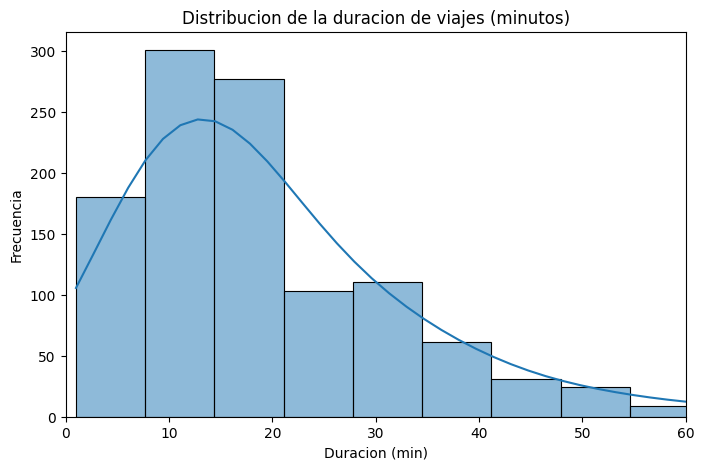

In [10]:
# Histograma de la duración de viajes en minutos
plt.figure(figsize=(8,5))

# Histplot
sns.histplot(df['DURACION_MIN'], bins=50, kde=True)

# Limitar eje X a 60 minutos para enfocar en la mayoria de los viajes, excluye outliers
plt.xlim(0,60)

# Titulos y etiquetas
plt.title("Distribucion de la duracion de viajes (minutos)")
plt.xlabel("Duracion (min)")
plt.ylabel("Frecuencia")

# Renderizar grafico
plt.show()

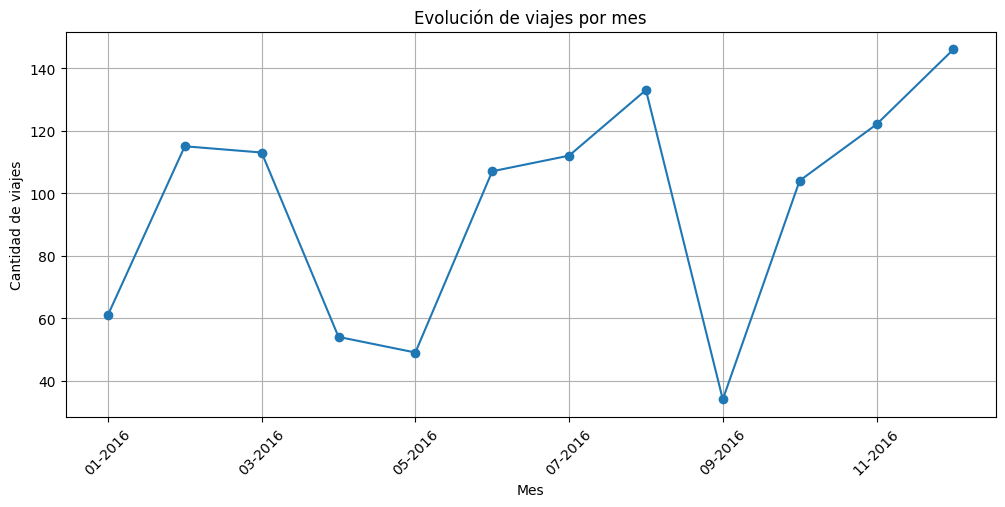

In [11]:
# Agrupar viajes por periodo Mes-Año y contar la cantidad de registros
viajes_mensuales = df.groupby('MES_AÑO').size()

# Evolucion mensual
plt.figure(figsize=(12,5))
viajes_mensuales.plot(kind='line', marker='o')

# Titulos y etiquetas
plt.title("Evolución de viajes por mes")
plt.xlabel("Mes")
plt.ylabel("Cantidad de viajes")

# Rotar etiquetas del eje X para mejor lectura
plt.xticks(rotation=45)

# Agregar grilla para facilitar la comparacion visual
plt.grid(True)

# Mostrar grafico
plt.show()

**Foco de Estudio**

Nos centraremos en la relación tiempo–lugar entre viajes consecutivos. Esta se definió como “coincidencia” aquellos casos en que un viaje comienza en la misma ubicación donde terminó el anterior y dentro de un intervalo máximo de 30 minutos. Esta condición permite aproximarse a la idea de continuidad, diferenciando simples coincidencias de movimientos que forman parte de un mismo patrón de desplazamiento. Además, se filtraron ubicaciones con un mínimo de 10 viajes posteriores para asegurar que los resultados reflejen tendencias y no eventos aislados

In [12]:
# Normalizacion de columnas categoricas clave
for c in ['CATEGORY','START','STOP','PURPOSE']:
    if c in df.columns:
        # Convertir todo a string y eliminar espacios extra
        df.loc[:, c] = df[c].astype(str).str.strip()

        # Reemplazar la cadena "nan" por valores NaN reales de numpy
        df.loc[:, c] = df[c].replace({'nan': np.nan})

        # Unificar formato en estilo Título, por ej. "new york" -> "New York"
        df.loc[:, c] = df[c].str.title()

In [13]:
# Ordenar viajes en forma cronológica por fecha de inicio
df = df.sort_values('START_DATE').reset_index(drop=True).copy()

# Calcular el intervalo en minutos entre el inicio del viaje actual y el fin del viaje anterior, shift(1) trae el END_DATE del registro previo
df.loc[:, 'INTERVALO_MINUTOS'] = (df['START_DATE'] - df['END_DATE'].shift(1)).dt.total_seconds() / 60

# Definir condiciones para considerar una coincidencia tiempo-lugar:
# 1) El viaje actual comienza en el mismo lugar donde termino el anterior
misma_ubic = df['START'] == df['STOP'].shift(1)

# 2) El intervalo está entre 0 y 30 minutos
intervalo_valido = df['INTERVALO_MINUTOS'].between(0, 30, inclusive='both')

# Marcar coincidencia si se cumplen ambas condiciones; en caso contrario "No"
df.loc[:, 'COINCIDENCIA_TIEMPO_LUGAR'] = np.where(misma_ubic & intervalo_valido, 'Sí', 'No')

# Guardar el destino del viaje anterior como referencia de agregacion por ubicacion
df.loc[:, 'STOP_PREV'] = df['STOP'].shift(1)

In [14]:
# Frecuencia global de coincidencia tiempo–lugar
# mean() sobre booleano: True=1, False=0
base_prob = (df['COINCIDENCIA_TIEMPO_LUGAR'] == 'Sí').mean()
print(f"Frecuencia global coincidencia tiempo-lugar: {base_prob:.2%}")

# Resumen por ubicacion (STOP_PREV) con metricas basicas
tmp = df.assign(evento=(df['COINCIDENCIA_TIEMPO_LUGAR'] == 'Sí').astype(int))
resumen = (
    tmp.groupby('STOP_PREV', dropna=True)
       .agg(
           viajes_posteriores=('evento','count'),          # volumen observado
           coincidencias=('evento','sum'),                 # veces que coincide
           prob_coincidencia=('evento','mean'),            # tasa de coincidencia
           intervalo_promedio=('INTERVALO_MINUTOS','mean') # media del intervalo
       )
)

# Percentiles de intervalo sobre casos con intervalo valido
pos = df[df['INTERVALO_MINUTOS'].ge(0)]
pcts = (pos.groupby('STOP_PREV')['INTERVALO_MINUTOS']
          .quantile([0.5, 0.9]).unstack(1)
          .rename(columns={0.5:'p50_intervalo', 0.9:'p90_intervalo'}))

# Unir percentiles y calcular lift vs. tasa global
resumen = resumen.join(pcts, how='left')
resumen['lift'] = resumen['prob_coincidencia'] / base_prob

# Ordenar por probabilidad descendente
resumen = resumen.sort_values('prob_coincidencia', ascending=False)

# Mostrar top bruto (sin filtro de volumen) para referencia
print("\nTop 10 ubicaciones por probabilidad (sin filtro de volumen):\n")
print(resumen.head(10))

# Filtro de robustez: minimo N observaciones por ubicacion
resumen_robusto = resumen[resumen['viajes_posteriores'] >= 10] \
                    .sort_values('prob_coincidencia', ascending=False)

print(f"\nTop ubicaciones robustas (≥{10} viajes posteriores):\n")
print(resumen_robusto.head(10))

Frecuencia global coincidencia tiempo-lugar: 19.65%

Top 10 ubicaciones por probabilidad (sin filtro de volumen):

                           viajes_posteriores  coincidencias  \
STOP_PREV                                                      
Almond                                      1              1   
Arlington Park At Amberly                   1              1   
Arabi                                       1              1   
Chalmette                                   1              1   
Briar Meadow                                1              1   
Hayesville                                  1              1   
Gampaha                                     1              1   
Farmington Woods                            1              1   
Florence                                    1              1   
Eagle Rock                                  1              1   

                           prob_coincidencia  intervalo_promedio  \
STOP_PREV                                       

**Hallazgos**

El analisis de coincidencia temporal-lugar muestra que ciertas ubicaciones tienen mayor probabilidad de generar un nuevo viaje en un periodo corto (<30 minutos) tras la finalizacion de uno anterior. Esto no significa que los viajes esten vinculados de forma determinista, sino que algunos puntos concentran patrones de continuidad mas frecuentes que el promedio.

Los resultados muestran dos niveles: un maximo sin filtrar, donde aparecen ubicaciones con pocas observaciones y porcentajes altos y poco fiables, y un máximo robusto, que considera solo las ubicaciones con un volumen minimo de viajes posteriores (10). Este segundo nivel es más util porque permite identificar áreas donde la recurrencia de viajes es constante.

In [15]:
# Filtrar ubicaciones con al menos 10 viajes posteriores
# Esto elimina casos poco representativos donde un 100% puede venir de solo 1 o 2 observaciones
resumen_filtrado = resumen[resumen['viajes_posteriores'] >= 10]

# Mostrar las 10 ubicaciones mas fuertes ordenadas por probabilidad de coincidencia
print("\nUbicaciones con minimo 10 viajes posteriores:\n")
print(resumen_filtrado.sort_values('prob_coincidencia', ascending=False).head(10))


Ubicaciones con minimo 10 viajes posteriores:

                  viajes_posteriores  coincidencias  prob_coincidencia  \
STOP_PREV                                                                
Edgehill Farms                    10              5           0.500000   
Westpark Place                    16              6           0.375000   
Islamabad                         57             20           0.350877   
Morrisville                       84             26           0.309524   
Apex                              17              4           0.235294   
Unknown Location                 147             34           0.231293   
Lahore                            36              7           0.194444   
Raleigh                           29              5           0.172414   
Kar?Chi                           26              4           0.153846   
Kenner                            10              1           0.100000   

                  intervalo_promedio  p50_intervalo  p90_interv

**Conclusión**

El análisis evidenció que, de manera global, solo el 5,19% de los viajes cumplen con la condición de coincidencia tiempo–lugar, lo que indica que la continuidad inmediata no es habitual. Sin embargo, al segmentar por ubicaciones específicas, se identificaron puntos donde la probabilidad es significativamente mayor, como Edgehill Farms y Morrisville. Este hallazgo abre la puerta a detectar zonas estratégicas donde los viajes tienden a repetirse en secuencias cortas. Con esta base analítica, el siguiente paso será la construcción de un dashboard en Power BI que traduzca estos patrones en visualizaciones claras y accionables.

In [16]:
# Exportar resultados a CSV
import os

# Definir ruta de salida (se crea carpeta 'outputs' si no existe)
output_dir = "outputs"
os.makedirs(output_dir, exist_ok=True)

# Exportar DataFrame principal
df.to_csv(os.path.join(output_dir, "uber_dataset_limpio.csv"), index=False, encoding="utf-8-sig")
print("Archivos CSV exportados en la carpeta 'outputs'.")

Archivos CSV exportados en la carpeta 'outputs'.
